In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import functionsTP as myfunc

<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\ferna\AppData\Local\Temp\ipykernel_11196\955314838.py:1: SyntaxWarning: invalid escape sequence '\I'
  image_path = 'images\Image2.jpg'


Text(0.5, 1.0, 'Original Image')

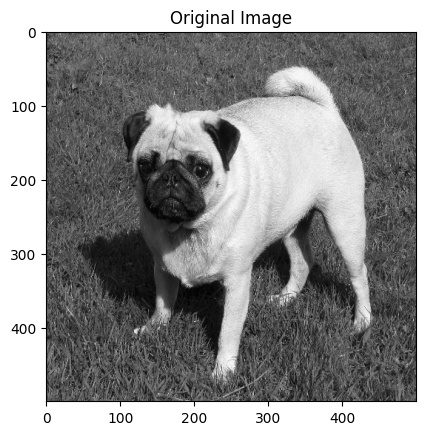

In [3]:
image_path = 'images\Image2.jpg'
L_image = cv2.imread(image_path)
L_image = cv2.resize(L_image, (500,500))
image = cv2.cvtColor(L_image, cv2.COLOR_BGR2GRAY)

plt.imshow(image, cmap='gray')
plt.title('Original Image')

iter 001: moved_frac=1.0000, M=9, curv_max=1.0343
iter 002: moved_frac=1.0000, M=9, curv_max=8.4528
iter 003: moved_frac=1.0000, M=9, curv_max=9.9154
iter 004: moved_frac=1.0000, M=9, curv_max=12.1514
iter 005: moved_frac=0.9917, M=9, curv_max=14.4294
iter 006: moved_frac=1.0000, M=9, curv_max=14.2915
iter 007: moved_frac=1.0000, M=9, curv_max=15.1939
iter 008: moved_frac=1.0000, M=9, curv_max=16.5275
iter 009: moved_frac=1.0000, M=9, curv_max=17.4289
iter 010: moved_frac=1.0000, M=9, curv_max=18.5711
iter 011: moved_frac=1.0000, M=9, curv_max=19.4168
iter 012: moved_frac=1.0000, M=9, curv_max=22.1765
iter 013: moved_frac=1.0000, M=9, curv_max=22.1765
iter 014: moved_frac=1.0000, M=9, curv_max=24.1341
iter 015: moved_frac=1.0000, M=9, curv_max=24.9515
iter 016: moved_frac=0.9917, M=9, curv_max=26.6239
iter 017: moved_frac=1.0000, M=9, curv_max=28.0040
iter 018: moved_frac=1.0000, M=9, curv_max=28.8505
iter 019: moved_frac=1.0000, M=9, curv_max=30.2282
iter 020: moved_frac=1.0000, M=9, 

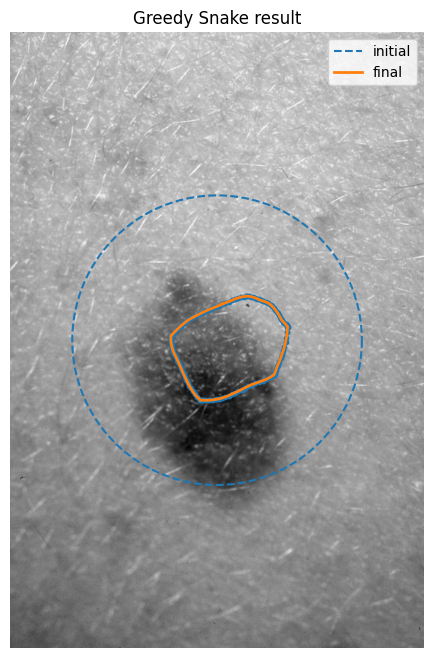

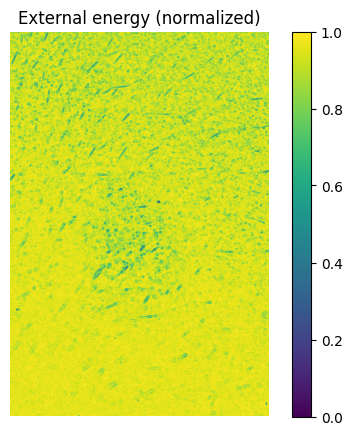

In [6]:
# -------------------------
# Example usage:
# -------------------------
if __name__ == "__main__":
    # image_path = r'images\synth-images\synthetic.jpg'  # your given path
    image_path = r'images\skin-waterloo\D36_2_orig.jpg'

    # Try to load the image
    try:
        img_bgr = cv2.imread(image_path)
        if img_bgr is None:
            raise FileNotFoundError(f"File not found or cannot be read: {image_path}")
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    except Exception as e:
        print("Warning:", e)
        # As fallback create a synthetic demo image (for debugging)
        print("Falling back to synthetic demo image (white square on black).")
        img_gray = np.zeros((300, 400), dtype=np.uint8)
        cv2.rectangle(img_gray, (80, 60), (320, 240), 255, thickness=-1)

    # Create an initial circular contour around center (if you don't have one)
    H, W = img_gray.shape
    center = np.array([W / 2, H / 2], dtype=float)
    R = min(H, W) * 0.35
    Npts = 120
    theta = np.linspace(0, 2 * np.pi, Npts, endpoint=False)
    init_pts = np.column_stack([center[0] + R * np.cos(theta),
                                center[1] + R * np.sin(theta)])

    # Run greedy snake
    final_pts, history, E_ext = myfunc.greedy_snake(img_gray, init_pts,
                                             alpha=0.1,
                                             beta=0.8,
                                             gamma=2.5,
                                             w_line=0.0,
                                             w_edge=1.0,
                                             sigma=1.0,
                                             M=9,
                                             max_iter=300,
                                             move_fraction_tol=0.008,
                                             corner_thresh_rel=0.5,
                                             shrink_M_if_stable=True,
                                             verbose=True)

    # Plot results
    myfunc.plot_snake(img_gray, init_pts, final_pts, E_ext=E_ext, title="Greedy Snake result")

